
# encoding mixed-integer problems as QUBO

Many optimization problems are defined with mized integers, such as rocket control problems where postion variables $x_t$ are continous variables no just binary. This doesn't cleaning map onto our QUBO annealers which require us to have $E=x^TQx$ where $x_i=\{0,1\}$. One of the main problems are encoding these continuous variables into binary, we'll follow this paper and its strategies.

<a id="ref-iftakher"></a>
[Iftakher et al. 2026] Iftakher, A., Türkay, M., & Hasan, M. M. F. *Solving mixed-integer problems as QUBO: Encodings, reformulations, and rolling-precision algorithm*. Computers & Chemical Engineering, 213 (2026), 109757. https://doi.org/10.1016/j.compchemeng.2026.109757


We have some main encodings in 

1. Simplest mixed $\mathbb{Z}$ encoding

    Take $x_t\in\mathbb{Z}$ with bounds $x_t=\in \{L_t,L_t+1,\cdots,U_t\}\subset\mathbb{Z}$. We define the range $R_t=U_t-L_t$, then with $B$ bits we can express $2^B$ distinct values $\{0,1,\cdots,2^B-1\}$. Hence we need $2^B-1\geq R_t$ to cover the range, and inverting $B_t=\log_2(R_t+1)$

    Then we introduce binary variables $z_{t,0},z_{t,1},\cdots,z_{t,2^B_t-1}=\{0,1\}$ and we can encode our integer variable as binary with.

    $x_t=L_t+\sum_{j=0}^{B_t-1}2^b z_{t,b}$ 

2. Decimal place expansions

    First take a continuous varibale $x^L_t\leq x_T\leq x^U_t$ now we scale our variable such that $\tilde x_t\in[0,1]$. Now,
    
     $\tilde x_t =\frac{x_t-x^L_t}{x_t^U-x_t^L}$ where $x_t=x_m^L+(x_m^U-x_m^L)\tilde x_t$

    From here we need to approximate $\tilde x_t$ with a finite decimal expansion of $J$ digits.

    $\tilde x_t = \underbrace{\sum_{j=1}^J \sum_{i=1}^{I=9} 10^{-j}z_{i,j,t}}_\text{J decimal places} + 10^{-J} z_{t,m}$

    Now $\sum_{j=1}^J 9\cdot 10^{-j}=1-10^{-J}$ hence we need an endpoint $+0^{-J}z_{t,m}$ so we can represent $1.000$. This is the simplest formulation but requires $(9J+1)$ binary variables per continous variable, this scales with $\sim9$ per decimal place. There are more effecient encodings such as the *weighted encoding with four bits per digit*.



3. Weighted encoding with four bits per digit
    
    $\tilde x_t = \underbrace{\sum_{j=1}^J 10^{-j}d_{t,j}}_\text{J decimal places} + \underbrace{10^{-J}z_{t,m}}_\text{endpoint bit}\\
    ~~= \underbrace{\sum_{j=1}^J 10^{-j}\left(z_{t,j,1}+2z_{t,j,2}+3z_{t,j,3}+3z_{t,j,4}\right)}_\text{weighted encoding with four bits per digit} + \underbrace{10^{-J}z_{t,m}}_\text{endpoint bit}$
    
    This choice of 4 bit encoding can get from $0\rightarrow (1+2+3+3)=9$ with only $(4J+1)$


These truncations have errors of $\text{error}\leq 10^{-J}$



# Mixed-integer optimal control

## 1D rocket control

The goal here is to construct an energy function $E=\textbf{x}^TQ\mathbf{x}$, where x are binary.T p

The general structure will be: 

$H_A$ enforcing the dynamics of the problem $x_{t+1}=f(x_t,u_t)$,

$H_B$ minimising fuel, 

$b_t$ binary control variable,

$x_t$ state variables, these require our encoding as continous variables.

### The dynamics

Lets first quickly dicuss the newtonian mechanics required for the dynamics of the problem
Lets define our parameters: 

$x(t)=$ height,

$\dot x(t)=v(t)=$ velocity,

$u(t)=$ engine thrust.

Firstly lets pick the simplest modle of thrust the engine is either on or off,

\begin{align*}u(t)=T_\text{max}b(t)\end{align*}.

Appliyng some newtonian mechanics to this 1D rocket problem,
\begin{align*}F=ma\\
    F=Tu_t-mg\\
    a_t=\frac{u}{m}u_t-g\end{align*}

We're left with our two equations $\begin{cases}
    \dot x=v\\
    \dot v=\frac{T\text{max}}{m}b(t)-g
\end{cases}$

#### Time discretisation

We then need to discretise time with the euler method for some tine step $\Delta t$

\begin{align*}x_{k+1}=x_k+\Delta t \dot x_k\\
x_{k+1}=x_k+\Delta t v_k\end{align*}

and

\begin{align*}v_{k+1}=v_k+\Delta t \dot v_k\\
v_{k+1}=v_k+\Delta t (\frac{T\text{max}}{m}b_k-g)\end{align*}

So we have, \begin{align*}\begin{cases}
    x_{k+1}=x_k+\Delta t v_k \\
    v_{k+1}=v_k+\Delta t (\frac{T\text{max}}{m}b_k-g)
\end{cases}\end{align*}

with $b_k\in\{0,1\}$ as our binary variables.

### Our problem

Now lets formulate this problem in a mixed-integer optimal control problem form, say our goal is: ***to land whilst firing the engine as few timesteps as possible***.

\begin{align*}
\min&\sum_{k=0}^{N-1}b_k \\
\text{s.t.}~~&x_{k+1}=x_k+\Delta t v_k \\
    &v_{k+1}=v_k+\Delta t(\frac{T\text{max}}{m}b_k-g) \\
    &x_N=0, ~~v_N=0\\
    &b_k\in\{0,1\}
\end{align*}



## Energy function

Now build ourselves a energy function for this problem,

\begin {align*}E=&E_\text{fuel}+E_\text{dynamics}+E_\text{end}\\
E_\text{fuel}&=\alpha\sum_{k=0}^{N-1}b_k\\
E_\text{dynamics}&=\beta(E_\text{x dynamics})+\gamma(E_\text{v dynamics})\\
 &= \beta\sum_{k=0}^{N-1}\left(x_{k+1}-x_k-\Delta t v_{k}\right)^2+\gamma\sum_{k=0}^{N-1}\left(v_{k+1}-v_k-\Delta t(\frac{T\text{max}}{m}b_k-g)\right)^2\\
E_\text{end}&=\sigma\left((x_N-x^\star)^2+(v_N-v^\star)^2\right)~~ \text{where }x^\star=v^\star=0
\end{align*}

Our full energy function becomes,

\begin{align*}E&= \alpha\sum_{k=0}^{N-1}b_k+ \beta\left(\sum_{k=0}^{N-1}(\underbrace{x_{k+1}}_\text{not binary}-\underbrace{x_k}_\text{not binary}-\Delta t \underbrace{v_{k}}_\text{not binary} )\right)^2+ \\ &~~\cdots+ \gamma\left(\sum_{k=0}^{N-1}(\underbrace{v_{k+1}}_\text{not binary}-\underbrace{v_k}_\text{not binary}-\Delta t(\frac{T\text{max}}{m}b_k-g))\right)^2+\sigma\left((x_N)^2+(v_N)^2\right)\end{align*}

### Weighted encoding with four bits per digit

\begin{align*}x_m&=x_m^\text{min}+(x_m^\text{max}-x_m^\text{min})\tilde x_t\\
&=x_m^\text{min}+(x_m^\text{max}-x_m^\text{min})\left( \sum_{j=1}^J 10^{-j}\left(x_{t,j,1}+2x_{t,j,2}+3x_{t,j,3}+3x_{t,j,4}\right) + 10^{-J}x_{t,m}\right)\end{align*}

and 

\begin{align*} v_m=v_m^\text{min}+(v_m^\text{max}-v_m^\text{min})\left( \sum_{j=1}^J 10^{-j}\left(v_{t,j,1}+2v_{t,j,2}+3v_{t,j,3}+3v_{t,j,4}\right) + 10^{-J}v_{t,m}\right)\end{align*}

We can then build ouselves a 

\begin{align*}E=\textbf{z}^TQ\mathbf{z}+c\end{align*}

with,

\begin{align*}\mathbf{z}=\left(b_0,\ldots,b_{N-1},\mathbf{x}_0,\ldots,\mathbf{x}_N,\mathbf{v}_0,\ldots,\mathbf{v}_N\right)^T\end{align*}

\begin{align*}\mathbf{x}_k=\left(x_{k,m},x_{k,1,1},x_{k,1,2},x_{k,1,3},x_{k,1,4},\ldots,x_{k,J,1},x_{k,J,2},x_{k,J,3},x_{k,J,4}\right)\end{align*}

and similarly,

\begin{align*} \mathbf{v}_k=\left(v_{k,1,1},v_{k,1,2},v_{k,1,3},v_{k,1,4},\ldots,v_{k,J,1},v_{k,J,2},v_{k,J,3},v_{k,J,4}\right).\end{align*}


### general expansion

Many of the penalty terms considered in this expansion are written in the form
\begin{align*}E=\lambda\left(C+\sum_i f_i z_i\right)^2,\end{align*}

where $C$ is a constant, $f_i$ are scalar coefficients, and
$z_i\in\{0,1\}$ are binary variables.

Expanding the square gives

\begin{align*}
E=\lambda\left(C^2+2C\sum_i f_i z_i+\sum_i\sum_j f_i f_j z_i z_j
\right).\end{align*}

Since the variables are binary, $z_i^2=z_i$, so

\begin{align*}
E
&=
\lambda C^2
+
\lambda\sum_i
\left(
f_i^2+2Cf_i
\right)z_i
+
2\lambda
\sum_{i<j}
f_i f_j z_i z_j.
\end{align*}

Therefore, the corresponding QUBO contributions are

\begin{align*}
Q_{ii}
&\mathrel{+}=
\lambda\left(f_i^2+2Cf_i\right),\\
Q_{ij}
&\mathrel{+}=
2\lambda f_i f_j,
\qquad i<j,
\end{align*}

while the constant contribution $\lambda C^2$ are dropped as it doesn't affect the minimum.

### Q

okay now we need to construct Q, this is best done each term at a time.

Firstly, the linear terms in $E_\text{fuel}$ which are diagonal down $b_k$

\begin{align*}E_\text{fuel}=\alpha\sum_{k=0}^{N-1}b_k\implies Q_{b_k,b_k}=+\alpha\end{align*}

Next,

\begin{align*}E_\text{end}=\sigma(x_N)^2+\sigma(v_N)^2\end{align*}

 but we need to encode our continous variable in binary,


\begin{align*}x_k=x_k^\text{min}+(x_k^\text{max}-x_k^\text{min})&\left( \sum_{j=1}^J 10^{-j}\left(x_{k,j,1}+2x_{k,j,2}+3x_{k,j,3}+3x_{k,j,4}\right) + 10^{-J}x_{k,end}\right)\\
x_k&= \underbrace{A^x}_{x_k^\text{min}}+w^x\cdot z_k^x\end{align*}

\begin{array}{cc}
\hline
\text{Variable} & \text{Weight } w_i^x \\
\hline
z^x_{k,1,1} & (x^{max}-x^{min}) \cdot 10^{-1} \cdot 1 \\
z^x_{k,1,2} & (x^{max}-x^{min}) \cdot 10^{-1} \cdot 2 \\
z^x_{k,1,3} & (x^{max}-x^{min}) \cdot 10^{-1} \cdot 3 \\
z^x_{k,1,4} & (x^{max}-x^{min}) \cdot 10^{-1} \cdot 3 \\
z^x_{k,2,1} & (x^{max}-x^{min}) \cdot 10^{-2} \cdot 1 \\
z^x_{k,2,2} & (x^{max}-x^{min}) \cdot 10^{-2} \cdot 2 \\
z^x_{k,2,3} & (x^{max}-x^{min}) \cdot 10^{-2} \cdot 3 \\
z^x_{k,2,4} & (x^{max}-x^{min}) \cdot 10^{-2} \cdot 3 \\
z^x_{k,end}   & (x^{max}-x^{min}) \cdot 10^{-2} \\
\hline
\end{array}


This lets us encode $E_\text{end}$,

\begin{align*}E_\text{end}&=\sigma(x_N)^2+\sigma(v_N)^2\\
E_\text{end}&=\sigma(A^x+w^x\cdot z_N^x)^2+\sigma(A^v+w^v\cdot z_N^v)^2\\
E_\text{end}&=\sigma (A^x)^2+\sigma(w^x\cdot z_N^x)^2 +2\sigma A^x w^x\cdot z_N^x+(A^v)^2+\sigma(w^v\cdot z_N^v)^2 +2\sigma A^v w^v\cdot z_N^v\\
E_\text{end} &= \underbrace{\sigma (A^x)^2 + \sigma (A^v)^2}_{\text{constant} \to c} + \underbrace{2\sigma A^x\sum_i w^x_i z^x_{N,i} + 2\sigma A^v\sum_i w^v_i z^v_{N,i}}_{\text{linear} \to Q_{ii}} + \\
&~~\cdots+\underbrace{\sigma \sum_i\sum_j w^x_i w^x_j z^x_{N,i} z^x_{N,j} + \sigma \sum_i\sum_j w^v_i w^v_j z^v_{N,i} z^v_{N,j}}_{\text{quadratic} \to Q_{ij}}\end{align*}

\begin{align*}
Q_{ii}
&\mathrel{+}=
\sigma\left((w_i)^2+2Aw_i\right),\\
Q_{ij}
&\mathrel{+}=
2\sigma w_iw_j,
\qquad i<j,
\end{align*}

Lastly, and most dfficulty the dynamics

\begin{align*}E_\text{dynamics}&=\beta(E_\text{x dynamics})+\gamma(E_\text{v dynamics})\\
 &= \beta\sum_{k=0}^{N-1}\left(x_{k+1}-x_k-\Delta t v_{k}\right)^2+\gamma\sum_{k=0}^{N-1}\left(v_{k+1}-v_k-\Delta t(\frac{T\text{max}}{m}b_k-g)\right)^2\end{align*}

We'll look at $\beta(E_\text{x dynamics})$ first,

\begin{align*}E_\text{x dynamics} &= \beta\sum_{k=0}^{N-1}(x_{k+1} - x_k - \Delta t v_k)^2\\
&=\beta\sum_{k=0}^{N-1}\left(A^x + \mathbf{w}^x\cdot\mathbf{z}^x_{k+1}) - (A^x + \mathbf{w}^x\cdot\mathbf{z}^x_k) - \Delta t(A^v + \mathbf{w}^v\cdot\mathbf{z}^v_k)\right)^2\\
&=\beta\sum_{k=0}^{N-1}\left(
\underbrace{-\Delta t A^v}_{\text{const}} + \underbrace{\sum_i w^x_i z^x_{k+1,i} - \sum_i w^x_i z^x_{k,i} - \Delta t\sum_i w^v_i z^v_{k,i}}_{\text{linear in }\mathbf{z}}
\right)^2\end{align*}




\begin{align*}f^x_{k,i} = \begin{cases} +w^x_i & z_i \in \mathbf{z}^x_{k+1} \\
 -w^x_i & z_i \in \mathbf{z}^x_k \\
  -\Delta tw^v_i & z_i \in \mathbf{z}^v_k \\\
   0 & \text{otherwise} \end{cases}\end{align*}


\begin{align*}
Q_{ii}& \mathrel{+}= \beta\left(f^x_{k,i}\right)^2 + 2\beta C^x_k f^x_{k,i} ,\text{ where }C^x_k=-\Delta tA^v\\
Q_{ij}& \mathrel{+}= 2\beta f^x_{k,i} f^x_{k,j} \quad i<j\end{align*}


Then we have Q,

\begin{align*}Q_{ii}& \mathrel{+}= \gamma\left(f^v_{k,i}\right)^2 + 2\gamma C^v_k f^v_{k,i}\\
Q_{ij}& \mathrel{+}= 2\gamma f^v_{k,i} f^v_{k,j} \qquad i < j\end{align*}

thats x


\begin{align*} E_\text{v dynamics} &= \gamma\sum_{k=0}^{N-1}\left(v_{k+1}-v_k-\Delta t(\frac{T\text{max}}{m}b_k-g)\right)^2\\
&=\gamma\sum_{k=0}^{N-1}\left(\underbrace{\Delta t g}_{\text{const}} + \underbrace{\sum_i w^v_i z^v_{k+1,i} - \sum_i w^v_i z^v_{k,i} - \Delta t\frac{T_{max}}{m}b_k}_{\text{linear in }\mathbf{z}}\right)^2\end{align*}

\begin{align*}f^v_{k,i} = \begin{cases} +w^v_i & z_i \in \mathbf{z}^v_{k+1} \\ -w^v_i & z_i \in \mathbf{z}^v_k \\ -\Delta t\dfrac{T_{max}}{m} & z_i = b_k \\ 0 & \text{otherwise} \end{cases}\end{align*}

Then we have Q,

\begin{align*}Q_{ii}& \mathrel{+}= \gamma\left(f^v_{k,i}\right)^2 + 2\gamma \Delta t g f^v_{k,i},\text{ where }C^v_k=\Delta tg\\
Q_{ij}& \mathrel{+}= 2\gamma f^v_{k,i} f^v_{k,j} \qquad i < j\end{align*}

collecting terms

\begin{align*}
    E_\text{fuel}&\implies Q_{b_k,b_k}=+\alpha\\\
    E_\text{end}&\implies\begin{cases}
    Q_{ii}
    &\mathrel{+}=
    \sigma\left((w_i)^2+2Aw_i\right),\\
    Q_{ij}
    &\mathrel{+}=
    2\sigma w_iw_j,
    \qquad i<j,
    \end{cases}\\
    E_\text{x dynamics}&=\begin{cases}
    Q_{ii} \mathrel{+}= \beta\left(f^x_{k,i}\right)^2 + 2\beta C^x_k f^x_{k,i}\\
    Q_{ij} \mathrel{+}= 2\beta f^x_{k,i} f^x_{k,j} \quad i<j\end{cases}\\
    E_\text{v dynamics}&=\begin{cases}
    Q_{ii} \mathrel{+}= \gamma\left(f^v_{k,i}\right)^2 + 2\gamma C^v_k f^v_{k,i}\\
    Q_{ij} \mathrel{+}= 2\gamma f^v_{k,i} f^v_{k,j} \qquad i < j\end{cases}
\end{align*}

Where, 
\begin{align*}C^v_k&=\Delta tg\\
C^x_k&=-\Delta tA^v \end{align*}

\begin{align*}f^x_{k,i} = \begin{cases} +w^x_i & z_i \in \mathbf{z}^x_{k+1} \\
 -w^x_i & z_i \in \mathbf{z}^x_k \\
  -\Delta tw^v_i & z_i \in \mathbf{z}^v_k \\\
   0 & \text{otherwise} \end{cases}&&
f^v_{k,i} = \begin{cases} +w^v_i & z_i \in \mathbf{z}^v_{k+1} \\ -w^v_i & z_i \in \mathbf{z}^v_k \\ -\Delta t\dfrac{T_{max}}{m} & z_i = b_k \\ 0 & \text{otherwise} \end{cases}\end{align*}
   

# imports

In [11]:
import numpy as np
from itertools import combinations

from numba import njit #optimization
import matplotlib.pyplot as plt

import time

#dwave
import tabu
import neal



# Building Q in python
We'll build this like last time however we'll build each $E_{i}$ in its own function.

First we need to index our variables.
$J$ are the decimals truncated for our continous variables,

 ie $J=2$ $x=2.23874\approx2.23$

1. control bits $b_k$
2. postion encoding bits $4J+1$
3. velocity encoding bits $4J+1$

## indexing

In [12]:
def idx(var, k, bit, N, J):

    B = 4 * J + 1
 
    if var == "b":
        return k
    elif var == "x":
        return N + k * B + bit
    elif var == "v":
        return N + (N + 1) * B + k * B + bit
    else:
        raise ValueError(f"Unknown variable type: {var!r}")

def num_vars(N, J):
    B = 4 * J + 1
    return N + 2 * (N + 1) * B

### small indexing example
This is a small written out example of our indexing

#### Controls (N = 3 variables)

0   $b_0$

1   $b_1$

2   $b_2$

#### Positions (N*B = 15 variables)

3   $x_0$ bit0


4   $x_0$ bit1

5   $x_0$ bit2

6   $x_0$ bit3

7   $x_0$ bit4

$\vdots$

16  $x_2$ bit3

17  $x_2$ bit4

#### Velocities (another 15 variables)

18  $v_0$ bit0

19  $v_0$ bit1

20  $v_0$ bit2

21 $v_0$ bit3

22  $v_0$ bit4

23  $v_1$ bit0

$\vdots$

32  $v_2$ bit4

Total $3+15+15=33$ but starting at $0, 32$


## Encoding x and v



Remember,

\begin{align*}x_k=x_k^\text{min}+(x_k^\text{max}-x_k^\text{min})&\left( \sum_{j=1}^J 10^{-j}\left(x_{k,j,1}+2x_{k,j,2}+3x_{k,j,3}+3x_{k,j,4}\right) + 10^{-J}x_{k,end}\right)\\
x_k&= \underbrace{A^x}_{x_k^\text{min}}+w^x\cdot z_k^x\end{align*}



In [13]:
def encoding_coeffs(lower, upper, J):

    span = upper - lower
    multipliers = [1, 2, 3, 3]
 
    weights = [span * 10 ** (-J)]
    for j in range(1, J + 1):
        scale = 10 ** (-j)
        weights.extend(span * scale * m for m in multipliers)
 
    return weights, lower


In [14]:
'''
wx, Ax = encoding_coeffs(0,100,J)

vals = set()

for mask in range(2**len(wx)):
    v = Ax
    for i,w in enumerate(wx):
        if (mask >> i) & 1:
            v += w
    vals.add(round(v,6))

print(min(vals), max(vals))
print(len(vals))'''

'\nwx, Ax = encoding_coeffs(0,100,J)\n\nvals = set()\n\nfor mask in range(2**len(wx)):\n    v = Ax\n    for i,w in enumerate(wx):\n        if (mask >> i) & 1:\n            v += w\n    vals.add(round(v,6))\n\nprint(min(vals), max(vals))\nprint(len(vals))'

## general squared exapnsion

Remember for,
\begin{align*}E=\lambda\left(C+\sum_i f_i z_i\right)^2,\end{align*}

We have, 

\begin{align*}
Q_{ii}
&\mathrel{+}=
\lambda\left(f_i^2+2Cf_i\right),\\
Q_{ij}
&\mathrel{+}=
2\lambda f_i f_j,
\qquad i<j,
\end{align*}

In [15]:
def add_square(Q, terms, C, lam):
    items = list(terms.items())
 
    for i, fi in items:
        Q[i, i] += lam * (fi ** 2 + 2 * C * fi)
 
    for (i, fi), (j, fj) in combinations(items, 2):
        lo, hi = (i, j) if i < j else (j, i) ## upper triangle
        Q[lo, hi] += 2 * lam * fi * fj
 

now since this energy fucntion is quite long each component will get its own function which we will call.

In [16]:
def add_fuel(Q, N, J, a):
    """E_fuel = alpha(now a) * sum_k b_k"""
    for k in range(N):
        i = idx("b", k, None, N, J)
        Q[i, i] += a
        
def add_boundary_cost(Q, N, J, weight, k, xmin, xmax, vmin, vmax,
                       x_target=0.0, v_target=0.0):
    """
    Generic pin: weight*(x_k - x_target)^2 + weight*(v_k - v_target)^2
 
    residual = x_k - x_target = (Ax + w^x . z_k) - x_target
             = (Ax - x_target) + w^x . z_k
    so C = Ax - x_target  (same trick as add_end_cost, just a nonzero target)
    """
    wx, Ax = encoding_coeffs(xmin, xmax, J)
    terms = {idx("x", k, bit, N, J): w for bit, w in enumerate(wx)}
    add_square(Q, terms, Ax - x_target, weight)
 
    wv, Av = encoding_coeffs(vmin, vmax, J)
    terms = {idx("v", k, bit, N, J): w for bit, w in enumerate(wv)}
    add_square(Q, terms, Av - v_target, weight)
 
 
def add_end_cost(Q, N, J, sigma, xN, vN, xmin, xmax, vmin, vmax):
    """E_end = sigma*(x_N-xN)^2 + sigma*(v_N-vN)^2  (pins the ending state)"""
    add_boundary_cost(Q, N, J, sigma, N, xmin, xmax, vmin, vmax,
                       x_target=xN, v_target=vN)
 
 
def add_initial_cost(Q, N, J, sigma, x0, v0, xmin, xmax, vmin, vmax):
    """E_start = sigma*(x_0-x0)^2 + sigma*(v_0-v0)^2  (pins the starting state)"""
    add_boundary_cost(Q, N, J, sigma, 0, xmin, xmax, vmin, vmax,
                       x_target=x0, v_target=v0)
    
def add_position_dynamics(Q, N, J, beta, dt, xmin, xmax, vmin, vmax):
    """E_x_dyn = beta * sum_k (x_{k+1} - x_k - dt*v_k)^2"""
    wx, Ax = encoding_coeffs(xmin, xmax, J)
    wv, Av = encoding_coeffs(vmin, vmax, J)
 
    #using .get(gi,0,0) sets =0 if we havent seen it before
    for k in range(N):
        terms = {}
        for bit, w in enumerate(wx):
            gi = idx("x", k + 1, bit, N, J)
            terms[gi] = terms.get(gi, 0.0) + w
        for bit, w in enumerate(wx):
            gi = idx("x", k, bit, N, J)
            terms[gi] = terms.get(gi, 0.0) - w
        for bit, w in enumerate(wv):
            gi = idx("v", k, bit, N, J)
            terms[gi] = terms.get(gi, 0.0) - dt * w
 
        # constant piece: Ax - Ax - dt*Av = -dt*Av
        C = -dt * Av
        add_square(Q, terms, C, beta)
 
def add_velocity_dynamics(Q, N, J, gamma, dt, g_grav, Tmax, mass, vmin, vmax):
    """E_v_dyn = gamma * sum_k (v_{k+1} - v_k - dt*(Tmax/m*b_k - g))^2"""
    wv, Av = encoding_coeffs(vmin, vmax, J)
 
    for k in range(N):
        terms = {}
        for bit, w in enumerate(wv):
            g_idx = idx("v", k + 1, bit, N, J)
            terms[g_idx] = terms.get(g_idx, 0.0) + w
        for bit, w in enumerate(wv):
            g_idx = idx("v", k, bit, N, J)
            terms[g_idx] = terms.get(g_idx, 0.0) - w
 
        b_i = idx("b", k, None, N, J)
        terms[b_i] = terms.get(b_i, 0.0) - dt * Tmax / mass
 
        # constant piece: Av - Av - dt*(0 - g) = dt*g
        C = dt * g_grav
        add_square(Q, terms, C, gamma)

In [17]:
def decode_solution(z, N, J, xmin, xmax, vmin, vmax):
    wx, Ax = encoding_coeffs(xmin, xmax, J)
    wv, Av = encoding_coeffs(vmin, vmax, J)
 
    b = [z[idx("b", k, None, N, J)] for k in range(N)]
 
    x = []
    for k in range(N + 1):
        bits = [z[idx("x", k, bit, N, J)] for bit in range(len(wx))]
        x.append(Ax + sum(w * bi for w, bi in zip(wx, bits)))
 
    v = []
    for k in range(N + 1):
        bits = [z[idx("v", k, bit, N, J)] for bit in range(len(wv))]
        v.append(Av + sum(w * bi for w, bi in zip(wv, bits)))
 
    return b, x, v

In [18]:
 
def check_feasibility(N, dt, xmin, xmax, vmin, vmax, g_grav, Tmax, mass,
                       x0, xN, verbose=True):
    """
    Sanity-checks a problem setup BEFORE building Q, catching the two classes
    of "physically impossible, no amount of weight-tuning will fix this" bugs:
 
      1. vmax/vmin too small (or N*dt too short) to cover the requested
         altitude change at all.
      2. thrust too weak to overcome gravity.
 
    Returns (ok: bool, issues: list[str]).
    """
    issues = []
 
    total_time = N * dt
    max_reach_up = total_time * vmax
    max_reach_down = total_time * vmin
    needed = xN - x0
 
    if needed > max_reach_up:
        issues.append(
            f"Target altitude change ({needed:+.1f}) exceeds the max possible "
            f"climb ({max_reach_up:+.1f} = N*dt*vmax = {N}*{dt}*{vmax}). "
            f"Raise vmax, raise N, or lower xN."
        )
    if needed < max_reach_down:
        issues.append(
            f"Target altitude change ({needed:+.1f}) exceeds the max possible "
            f"descent ({max_reach_down:+.1f} = N*dt*vmin = {N}*{dt}*{vmin}). "
            f"Lower vmin (more negative), raise N, or raise xN."
        )
 
    if not (xmin <= x0 <= xmax):
        issues.append(f"x0={x0} lies outside the encodable range [{xmin}, {xmax}].")
    if not (xmin <= xN <= xmax):
        issues.append(f"xN={xN} lies outside the encodable range [{xmin}, {xmax}].")
 
    thrust_accel = Tmax / mass - g_grav
    if thrust_accel <= 0:
        issues.append(
            f"Thrust acceleration (Tmax/mass - g_grav = {thrust_accel:.4f}) is <= 0 "
            f"-- the engine cannot overcome gravity at all. Increase Tmax or decrease mass."
        )
    elif thrust_accel < g_grav:
        issues.append(
            f"Thrust acceleration ({thrust_accel:.4f}) is weaker than gravity "
            f"({g_grav}) -- the engine works but only barely. Consider a bigger margin."
        )
 
    ok = len(issues) == 0
    if verbose:
        if ok:
            print("[check_feasibility] OK")
        else:
            print("[check_feasibility] problems found:")
            for msg in issues:
                print("  -", msg)
 
    return ok, issues
 
 

In [19]:
def build_rocket_qubo(N, J, dt, a, beta, gamma, sigma,
                       xmin, xmax, vmin, vmax, g_grav, Tmax, mass,
                       x0, v0, xN, vN, sigma_start=None):
    """
    x0, v0        : starting altitude/velocity (pinned via add_initial_cost)
    xN, vN        : target ending altitude/velocity (pinned via add_end_cost)
                    default 0.0, 0.0 -> "landing" (come to rest at the ground)
                    set x0=0, xN=<something> -> "takeoff" (start at the ground,
                    reach a target altitude)
    sigma_start   : weight for the initial-condition term; defaults to `sigma`
                    (same weight as the end-condition term) if not given
    """
    
    #check_feasibility(N, dt, xmin, xmax, vmin, vmax, g_grav, Tmax, mass,
                    #   x0, xN, verbose=True)
    
    
    if sigma_start is None:
        sigma_start = sigma
 
    n = num_vars(N, J)
    Q = np.zeros((n, n))
 
    add_fuel(Q, N, J, a)
    add_position_dynamics(Q, N, J, beta, dt, xmin, xmax, vmin, vmax)
    add_velocity_dynamics(Q, N, J, gamma, dt, g_grav, Tmax, mass, vmin, vmax)
    add_initial_cost(Q, N, J, sigma_start, x0, v0, xmin, xmax, vmin, vmax)
    add_end_cost(Q, N, J, sigma, xN, vN, xmin, xmax, vmin, vmax)
    Q = (Q + Q.T)/2.0
    return Q 

## plotting


In [20]:
def plot_trajectory(b, x, v, dt, savepath=None):
    """
    b : list/array, length N      (engine on/off per interval)
    x : list/array, length N+1    (altitude at each timestep)
    v : list/array, length N+1    (velocity at each timestep)
    dt: timestep size
    """
    N = len(b)
    t_states = np.arange(N + 1) * dt   # times for x, v  (k = 0..N)
    t_b = np.arange(N) * dt            # times for b     (k = 0..N-1, one per interval)
 
    fig, axes = plt.subplots(3, 1, figsize=(8, 7), sharex=True)
 
    # --- altitude ---
    axes[0].plot(t_states, x, "o-", color="tab:blue")
    axes[0].axhline(0, color="gray", linestyle="--", linewidth=1)
    axes[0].set_ylabel("altitude  x(t)")
    axes[0].set_title("Rocket trajectory")
 
    # --- velocity ---
    axes[1].plot(t_states, v, "o-", color="tab:orange")
    axes[1].axhline(0, color="gray", linestyle="--", linewidth=1)
    axes[1].set_ylabel("velocity  v(t)")
 
    # --- engine on/off ---
    # step plot: b[k] is constant over the interval [t_k, t_k+1)
    axes[2].step(t_b, b, where="post", color="tab:red", linewidth=2)
    axes[2].fill_between(t_b, b, step="post", alpha=0.2, color="tab:red")
    axes[2].set_ylabel("engine  b(t)")
    axes[2].set_ylim(-0.1, 1.1)
    axes[2].set_yticks([0, 1])
    axes[2].set_xlabel("time")
 
    fig.tight_layout()
 
    if savepath:
        fig.savefig(savepath, dpi=150)
    return fig

# annealing qubo

We need to employ some annealing to our QUBO, we need to improve it slightlty.  

inputting `T_start, T_end,` requires us to know the scale of $dE$ since

\begin{align*}p=e^{dE/T}\end{align*}

so the ratio $\frac{dE}{T}$ matters. If we set some acceptance probability we want then we can set the corresponding temp,

\begin{align*}T=\frac{-dE}{\ln p}\end{align*}


 We can compute some random $dE$ s from random $\vec x$ and get a mean for the scale.


In [22]:
def estimate_temperature_range(Q, n_samples=100, hot_accept_prob=0.5, cold_accept_prob=1e-3):
    n = Q.shape[0]
    all_dEs = []

    for _ in range(n_samples):
        x = np.random.choice(np.array([0, 1]), size=n).astype(np.float64)
        for i in range(n):
            dE = delta_energy(x, Q, i)
            all_dEs.append(abs(dE))

    all_dEs = np.array(all_dEs)
    all_dEs = all_dEs[all_dEs > 0]   # ignore zero-moves, they don't inform temperature scale

    dE_typical = np.percentile(all_dEs, 50)   # median dE, for T_start
    dE_small   = np.percentile(all_dEs, 5)    # a small dE, for T_end

    T_start = -dE_typical / np.log(hot_accept_prob)
    T_end   = -dE_small / np.log(cold_accept_prob)

    return T_start, T_end, all_dEs

def estimate_runtime(Q, total_sweeps, n_reads, n_timing_sweeps=1000, T_test=100.0, n_timing_repeats=8):
    n = Q.shape[0]
    x = np.random.choice([0, 1], size=n).astype(np.float64)
    E = energy_QUBO(x, Q)
    _ = sweep_once_QUBO(x, Q, T_test, E)  # JIT warm-up

    sweep_times = []
    for _ in range(n_timing_repeats):
        start = time.time()
        for _ in range(n_timing_sweeps):
            E = sweep_once_QUBO(x, Q, T_test, E)
        sweep_times.append((time.time() - start) / n_timing_sweeps)

    time_per_sweep = np.median(sweep_times)
    time_per_read = time_per_sweep * total_sweeps
    time_total = time_per_read * n_reads

    print(f"time per sweep (median of {n_timing_repeats}): {time_per_sweep*1000:.4f} ms  (range: {min(sweep_times)*1000:.4f}-{max(sweep_times)*1000:.4f} ms)")
    print(f"time per full anneal: {time_per_read:.2f} s")
    if n_reads > 1:
        print(f"time for {n_reads} reads: {time_total/60:.2f} min ({time_total:.2f} s)")

    return time_per_sweep, time_per_read, time_total

def estimate_runtime_converge_fast(Q, T_start, T_end, alpha, window, tol, n_reads,
                                     n_probe_early=10, n_probe_late=10,
                                      max_sweeps=5000):
    n = Q.shape[0]
    x = np.random.choice([0, 1], size=n).astype(np.float64)
    E = energy_QUBO(x, Q)

    _ = sweep_once_QUBO(x, Q, 100.0, E)  # JIT warm-up

    start = time.time()
    for _ in range(1000):
        E = sweep_once_QUBO(x, Q, 100.0, E)
    time_per_sweep = (time.time() - start) / 1000

    _ = sweep_until_converged(x, Q, T_start, E, window, tol, max_sweeps)  # JIT warm-up

    num_temp_steps_total = int(np.log(T_end / T_start) / np.log(alpha))

    # --- probe early steps (run the real schedule from the start) ---
    x_probe = np.random.choice([0, 1], size=n).astype(np.float64)
    E_probe = energy_QUBO(x_probe, Q)
    T = T_start
    early_sweeps = []

    n_early = min(n_probe_early, num_temp_steps_total)
    for _ in range(n_early):
        E_probe, s_done = sweep_until_converged(x_probe, Q, T, E_probe, window, tol, max_sweeps)
        early_sweeps.append(s_done)
        T *= alpha

    # --- jump ahead to probe late steps ---
    n_late = max(0, min(n_probe_late, num_temp_steps_total - n_early))   # <-- CHANGED: clamp to >= 0

    late_sweeps = []
    if n_late > 0:                                                        # <-- CHANGED: guard the block
        T_late_start = T_end / (alpha ** n_late)
        T = max(T, T_late_start)

        for _ in range(n_late):
            E_probe, s_done = sweep_until_converged(x_probe, Q, T, E_probe, window, tol, max_sweeps)
            late_sweeps.append(s_done)
            T *= alpha

    # --- combine estimate ---
    all_probe_sweeps = early_sweeps + late_sweeps
    avg_sweeps_per_step = np.mean(all_probe_sweeps)
    est_total_sweeps = avg_sweeps_per_step * num_temp_steps_total
    est_time_per_read = time_per_sweep * est_total_sweeps

    print(f"time per sweep:             {time_per_sweep*1000:.4f} ms")
    print(f"estimated time per anneal:  {est_time_per_read:.2f} s")

    time_total = est_time_per_read * n_reads
    if n_reads > 1:
        print(f"estimated time for {n_reads} reads: {time_total/60:.2f} min ({time_total:.2f} s)")

    return time_per_sweep, est_time_per_read, time_total, est_total_sweeps

In [23]:
@njit
def energy_QUBO(x, Q):
    return x @ Q @ x

def sim_annealing_QUBO(Q, alpha, sweeps_per_T,verbose=False):
    T_start, T_end, _ = estimate_temperature_range(Q,
        n_samples=100, hot_accept_prob=0.5, cold_accept_prob=1e-3)
    
    if verbose==True:
        print(f"Starting temp: {T_start:.2f}\nEnding temp: {T_end:.2f}")
        
        num_temp_steps = np.log(T_end / T_start) / np.log(alpha)
        total_sweeps = sweeps_per_T * num_temp_steps
        #print(f"temp steps: {num_temp_steps:.2f}")
        #print(f"total sweeps: {total_sweeps:.2f}")
    
        estimate_runtime(Q, total_sweeps, n_reads, n_timing_sweeps=100, T_test=100.0)
    
    n = Q.shape[0]
    x = np.random.choice(np.array([0, 1]), size=n).astype(np.float64)

    E = energy_QUBO(x, Q)

    temps = []
    energies = []
    sweeps_used = []


    T = T_start
    
    while T > T_end:
        for _ in range(sweeps_per_T):
            E = sweep_once_QUBO(x, Q, T, E)
        
        temps.append(T)
        energies.append(E)
        T *= alpha
        
    return np.array(temps), np.array(energies), x.copy()
    
    
# same idea but now swapping the sweep
   
def sim_annealing_QUBO_converge(Q, alpha, window=50, tol=1e-3, max_sweeps=5000,verbose=False):
    
    T_start, T_end, _ = estimate_temperature_range(Q,
        n_samples=20, hot_accept_prob=0.5, cold_accept_prob=1e-3)
    
    if verbose==True:
        print(f"Starting temp: {T_start:.2f}\nEnding temp: {T_end:.2f}")
        estimate_runtime_converge_fast(Q, T_start, T_end, alpha, window, tol,
            n_reads,n_probe_early=10, n_probe_late=1, max_sweeps=5000)
            
    n = Q.shape[0]
    x = np.random.choice(np.array([0, 1]), size=n).astype(np.float64)

    E = energy_QUBO(x, Q)

    temps = []
    energies = []
    sweeps_used = []


    T = T_start
    
    while T > T_end:
        E, s_done = sweep_until_converged(x, Q, T, E, window, tol, max_sweeps)

        #test
        #E_true = energy_QUBO(x,Q)
        #print(T, E-E_true)

        temps.append(T)
        energies.append(E)
        sweeps_used.append(s_done)
        
        T *= alpha
    
    return np.array(temps), np.array(energies), x.copy()

@njit
def delta_energy(x, Q, i):
    s = 0.0
    N = len(x)

    for j in range(N):
        if j != i:
            s += Q[i, j] * x[j]

    if x[i] == 0:
        # 0 -> 1
        return Q[i, i] + 2.0 * s
    else:
        # 1 -> 0
        return -(Q[i, i] + 2.0 * s)

@njit
def sweep_once_QUBO(x, Q, T, E):

    N = len(x)

    for _ in range(N):

        i = np.random.randint(N)

        dE = delta_energy(x, Q, i)

        if dE < 0 or np.random.rand() < np.exp(-dE / T):

            x[i] = 1 - x[i]
            E += dE

    return E

@njit
def sweep_until_converged(x, Q, T, E, window=50, tol=1e-3, max_sweeps=5000):
    recent_energies = np.zeros(window)
    sweeps_done = 0
    for s in range(max_sweeps):
        E = sweep_once_QUBO(x, Q, T, E)
        recent_energies[s % window] = E
        sweeps_done += 1
        if s >= window:
            spread = recent_energies.max() - recent_energies.min()
            if spread < tol * abs(E):
                break
    return E, sweeps_done

# finding the minma of Q

In [14]:
params = dict(
    N=20,
    J=1,
    dt=0.5,

    a=0,
    beta=1000,
    gamma=1000,
    sigma=1000,

    xmin=0,
    xmax=10,

    vmin=-10,
    vmax=10,

    g_grav=10,

    Tmax=20,
    mass=1,

    x0=0,
    v0=0,

    xN=10,
    vN=0,
)

Q = build_rocket_qubo(**params)

T_start, T_end, alpha, sweeps_per_T = 80000, 1, 0.97, 2000

temps, energies, x_final = sim_annealing_QUBO(Q,T_start,T_end,alpha,sweeps_per_T)

b, x, v = decode_solution(x_best, params["N"], params["J"],
                           params["xmin"], params["xmax"],
                           params["vmin"], params["vmax"])

print("b:",b)
print("x:",x)
print("v:",v)


fig = plot_trajectory(b, x, v, dt=0.5, savepath="landing.png")
b, x, v = decode_solution(x_best, params["N"], params["J"],
                           params["xmin"], params["xmax"],
                           params["vmin"], params["vmax"])
 

TypeError: sim_annealing_QUBO() takes from 3 to 4 positional arguments but 5 were given

these results aren't valid solutions nevermind optimal.

I believe that we arent finding a minima with our annealer code. Lets employ other peoples libraries.

## is it minima?

lets first average my annealers solutions

In [ ]:
params = dict(
    N=10,
    J=3,
    dt=0.5,

    a=10,
    beta=1000,
    gamma=1000,
    sigma=1000,

    xmin=0,
    xmax=10,

    vmin=0,
    vmax=10,

    g_grav=10,

    Tmax=20,
    mass=1,

    x0=0,
    v0=0,

    xN=10,
    vN=0,
)

Q = build_rocket_qubo(**params)

T_start, T_end, alpha, sweeps_per_T = 80000, 1, 0.96, 2000


n_reads = 1500
'''
#mine
my_energies = np.zeros(n_reads)

sim_annealing_QUBO(Q, alpha, sweeps_per_T, verbose=True)  # just for the printed estimate

start = time.time()
for r in range(n_reads):
    temps, energies, x_final = sim_annealing_QUBO(Q,alpha,sweeps_per_T,verbose=False)
    my_energies[r] = energies[-1]

print(f"actual time of my original annealer: {time.time() - start:.2f}s")   
print("my original annealer  -> min:", my_energies.min(), " std:", my_energies.std())


print("\n")
#'''
my_converged_energies=np.zeros(n_reads)

start = time.time()
window, tol =50, 1
'''
sim_annealing_QUBO_converge(Q,alpha, window, tol, max_sweeps=7000,verbose=True)

for r in range(n_reads):
    temps, energies, x_final = sim_annealing_QUBO_converge(Q,
        alpha, window, tol, max_sweeps=7000, verbose=False)
    #test
    #print("tracked :", energies[-1])
    #print("actual  :", x_final @ Q @ x_final)
    my_converged_energies[r] = energies[-1]

print(f"actual time of my converging annealer: {time.time() - start:.2f}s")
print("my converging annealer  -> min:", my_converged_energies.min(), " std:", my_converged_energies.std())
'''
print("\n")
#'''
 
# build Q dic for dwave
'''
Q_matrix = build_rocket_qubo(**params)
Q_dict = {}
n = Q_matrix.shape[0]
for i in range(n):
    for j in range(i, n):
        if Q_matrix[i, j] != 0:
            Q_dict[(i, j)] = Q_matrix[i, j]
#'''
Q_dict = {}
n=np.shape(Q)[0]
for i in range(n):
    Q_dict[(i, i)] = Q[i, i]

for i in range(n):
    for j in range(i + 1, n):
        if Q[i, j] != 0:
            Q_dict[(i, j)] = 2 * Q[i, j]

# dwave neal
sampler = neal.SimulatedAnnealingSampler()
start = time.time()
sampleset = sampler.sample_qubo(Q_dict, num_reads=n_reads, num_sweeps=5000)
neal_energies = sampleset.record.energy 
print(f"time for neal: {time.time() - start:.2f}s")
print("neal         -> min:",neal_energies.min(), " std:", neal_energies.std()) 

print("\n")

# dwave tabu
start = time.time()
tabu_sampler = tabu.TabuSampler()
tabu_sampleset = tabu_sampler.sample_qubo(Q_dict, num_reads=n_reads)
tabu_energies = tabu_sampleset.record.energy
print(f"time for tabu: {time.time() - start:.2f}s")
print("tabu -> min:", tabu_energies.min(), " std:", tabu_energies.std())


NameError: name 'shape' is not defined

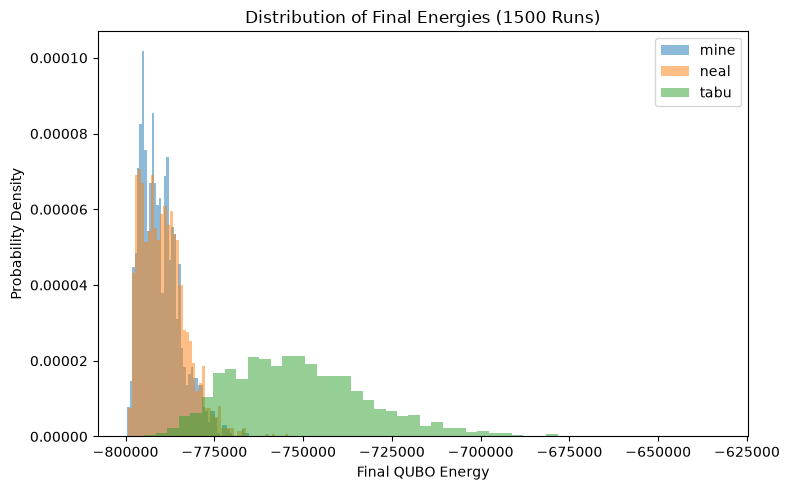

In [ ]:
plt.figure(figsize=(8,5))

bins = 50

plt.hist(my_converged_energies,
         bins=bins,
         density=True,
         alpha=0.5,
         label='mine')

plt.hist(neal_energies,
         bins=bins,
         density=True,
         alpha=0.5,
         label='neal')

plt.hist(tabu_energies,
         bins=bins,
         density=True,
         alpha=0.5,
         label='tabu')
'''
# Mean lines
plt.axvline(my_converged_energies.mean(),
            linestyle='--',
            linewidth=2)

plt.axvline(neal_energies.mean(),
            linestyle='--',
            linewidth=2)

plt.axvline(tabu_energies.mean(),
            linestyle='--',
            linewidth=2)
'''
plt.xlabel("Final QUBO Energy")
plt.ylabel("Probability Density")
#plt.title("Distribution of Final Energies (1500 Runs)")
plt.legend()
plt.tight_layout()
plt.savefig("/home/cian/Documents/college/SURE/git/QUBO/optimal-control")
plt.show()

# testing

In [ ]:
sample = sampleset.first.sample
x_neal = np.array([sample[i] for i in range(n)], dtype=float)

print("Matrix energy :", x_neal @ Q @ x_neal)
print("Neal energy   :", sampleset.first.energy)

Matrix energy : -656480.0
Neal energy   : -556940.7999999964


In [ ]:
print(np.array_equal(Q, Q_matrix))
print(np.max(np.abs(Q - Q_matrix)))


print(np.allclose(Q, Q.T))
sample = sampleset.first.sample
x = np.array([sample[i] for i in range(n)])
print(x @ Q @ x)
print(sampleset.first.energy)

True
0.0
True
-658300.0
-557940.7999999969


In [ ]:
import time

def time_one_batch(Q, n_timing_sweeps=1000, T_test=100.0):
    n = Q.shape[0]
    x = np.random.choice([0, 1], size=n).astype(np.float64)
    E = energy_QUBO(x, Q)
    _ = sweep_once_QUBO(x, Q, T_test, E)  # warm up

    start = time.time()
    for _ in range(n_timing_sweeps):
        E = sweep_once_QUBO(x, Q, T_test, E)
    return (time.time() - start) / n_timing_sweeps

for i in range(8):
    t = time_one_batch(Q)
    print(f"run {i}: {t*1000:.4f} ms/sweep")

run 0: 0.1377 ms/sweep
run 1: 0.1860 ms/sweep
run 2: 0.1942 ms/sweep
run 3: 0.1615 ms/sweep
run 4: 0.1867 ms/sweep
run 5: 0.1624 ms/sweep
run 6: 0.1640 ms/sweep
run 7: 0.1537 ms/sweep


# run it with the minima 

what are are parameters 

$\alpha$ fuel constraint

$\sigma$ ending and starting constraints

$\beta$ postion constraint

$\gamma$ velocity constraint



In [ ]:
params = dict(
    N=20,
    J=1,
    dt=0.5,

    a=2,
    beta=10000*10,
    gamma=10000,
    sigma=10000,

    xmin=0,
    xmax=10,

    vmin=0,
    vmax=20,

    g_grav=10,

    Tmax=20,
    mass=1,

    x0=0,
    v0=0,

    xN=10,
    vN=10,
)


In [ ]:
params = dict(
    N=20,
    J=1,
    dt=0.5,

    a=2,
    beta=10000*10,
    gamma=10000,
    sigma=10000,

    xmin=0,
    xmax=10,

    vmin=0,
    vmax=20,

    g_grav=10,

    Tmax=20,
    mass=1,

    x0=0,
    v0=0,

    xN=10,
    vN=10,
)

n_reads = 1

Q = build_rocket_qubo(**params)

temps, energies, x_best = sim_annealing_QUBO_converge(Q,
        alpha=0.98, window=50, tol=10e-3, max_sweeps=10000,verbose=True)

b, x, v = decode_solution(x_best, params["N"], params["J"],
                           params["xmin"], params["xmax"],
                           params["vmin"], params["vmax"])

print("b:",b)
print("x:",x)
print("v:",v)


fig = plot_trajectory(b, x, v, dt=0.5, savepath="landing.png")
'''
b, x, v = decode_solution(x_best, params["N"], params["J"],
                           params["xmin"], params["xmax"],
                           params["vmin"], params["vmax"])
 #'''

NameError: name 'build_rocket_qubo' is not defined

# fix our solution


In [ ]:
def term_energy(Q_component, x):
    return x @ Q_component @ x

N, J = params["N"], params["J"]
dt = params["dt"]
a, beta, gamma, sigma = params["a"], params["beta"], params["gamma"], params["sigma"]
xmin, xmax = params["xmin"], params["xmax"]
vmin, vmax = params["vmin"], params["vmax"]
g_grav, Tmax, mass = params["g_grav"], params["Tmax"], params["mass"]
x0, v0, xN, vN = params["x0"], params["v0"], params["xN"], params["vN"]

Q = build_rocket_qubo(**params)

n = Q.shape[0]

Q_fuel = np.zeros((n, n)); add_fuel(Q_fuel, N, J, a)
Q_pos  = np.zeros((n, n)); add_position_dynamics(Q_pos, N, J, beta, dt, xmin, xmax, vmin, vmax)
Q_vel  = np.zeros((n, n)); add_velocity_dynamics(Q_vel, N, J, gamma, dt, g_grav, Tmax, mass, vmin, vmax)
Q_init = np.zeros((n, n)); add_initial_cost(Q_init, N, J, sigma, x0, v0, xmin, xmax, vmin, vmax)
Q_end  = np.zeros((n, n)); add_end_cost(Q_end, N, J, sigma, xN, vN, xmin, xmax, vmin, vmax)

print(f"{'term':<15}{'energy':>15}")
for name, Qc in [("fuel", Q_fuel), ("position_dyn", Q_pos), ("velocity_dyn", Q_vel),
                 ("initial", Q_init), ("end", Q_end)]:
    Qc_sym = (Qc + Qc.T) / 2.0
    e = term_energy(Qc_sym, x_best)
    print(f"{name:<15}{e:>15.2f}")

print(f"\n{'total (sum of parts)':<15}{sum(term_energy((Qc+Qc.T)/2.0, x_best) for _, Qc in [('fuel', Q_fuel), ('position_dyn', Q_pos), ('velocity_dyn', Q_vel), ('initial', Q_init), ('end', Q_end)]):>15.2f}")
print(f"{'total (full Q)':<15}{energy_QUBO(x_best, Q):>15.2f}")

def check_dynamics_residuals(b, x, v, dt, Tmax, mass, g_grav):
    N = len(b)
    pos_residuals = []
    vel_residuals = []
    
    for k in range(N):
        # position dynamics: x_{k+1} - x_k - dt*v_k should be ~0
        pos_resid = x[k+1] - x[k] - dt * v[k]
        pos_residuals.append(pos_resid)
        
        # velocity dynamics: v_{k+1} - v_k - dt*(Tmax/mass*b_k - g_grav) should be ~0
        vel_resid = v[k+1] - v[k] - dt * (Tmax/mass * b[k] - g_grav)
        vel_residuals.append(vel_resid)
    
    pos_residuals = np.array(pos_residuals)
    vel_residuals = np.array(vel_residuals)
    
    print("position residuals per step:", np.round(pos_residuals, 3))
    print("velocity residuals per step:", np.round(vel_residuals, 3))
    print(f"\nmax |position residual|: {np.abs(pos_residuals).max():.3f}")
    print(f"max |velocity residual|: {np.abs(vel_residuals).max():.3f}")
    print(f"mean |position residual|: {np.abs(pos_residuals).mean():.3f}")
    print(f"mean |velocity residual|: {np.abs(vel_residuals).mean():.3f}")
    
    return pos_residuals, vel_residuals

pos_res, vel_res = check_dynamics_residuals(b, x, v, params["dt"], params["Tmax"], params["mass"], params["g_grav"])

term                    energy
fuel                     22.00
position_dyn         700000.00
velocity_dyn       -4320000.00
initial                   0.00
end                -2000000.00

total (sum of parts)    -5619978.00
total (full Q)     -5619978.00
position residuals per step: [ 0.  0.  0.  0.  0. -1. -1.  0. -1.  0.  0.  0. -1. -1. -1.  0. -1.  0.
  0.  0.]
velocity residuals per step: [-1.  1. -1.  1. -3.  3. -3.  3. -1.  1. -1.  1. -3.  3. -1.  1. -1.  1.
 -1.  1.]

max |position residual|: 1.000
max |velocity residual|: 3.000
mean |position residual|: 0.350
mean |velocity residual|: 1.600


In [ ]:
# rerun with beta pushed way up, everything else fixed, more sweeps
params_test = {**params, "beta": params["beta"] * 10}
Q_test = build_rocket_qubo(**params_test)
temps, energies, x_best_test = sim_annealing_QUBO_converge(Q_test, alpha=0.98, window=50, tol=1e-3, max_sweeps=20000, verbose=True)
b2, x2, v2 = decode_solution(x_best_test, params_test["N"], params_test["J"], params_test["xmin"], params_test["xmax"], params_test["vmin"], params_test["vmax"])
pos_res2, vel_res2 = check_dynamics_residuals(b2, x2, v2, params["dt"], params["Tmax"], params["mass"], params["g_grav"])

Starting temp: 18791102.91
Ending temp: 98440.08
time per sweep:             0.0368 ms
estimated time per anneal:  47.67 s
position residuals per step: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
velocity residuals per step: [-5.  1. -3.  3. -3. -5.  3. -5.  5.  5. -5.  7.  3.  5.  5.  5. -3.  3.
 -3.  1.]

max |position residual|: 0.000
max |velocity residual|: 7.000
mean |position residual|: 0.000
mean |velocity residual|: 3.900


Starting temp: 1066151.64
Ending temp: 2547.86
time per sweep:             0.1356 ms
estimated time per anneal:  99.68 s
position residuals per step: [-0.045 -0.345 -0.28  -0.635 -0.755 -0.72  -0.74  -0.51  -0.195 -0.265]
velocity residuals per step: [-0.76  0.76 -1.64  1.64 -1.66  1.66 -1.    1.   -1.08  0.02]

max |position residual|: 0.755
max |velocity residual|: 1.660
mean |position residual|: 0.449
mean |velocity residual|: 1.122


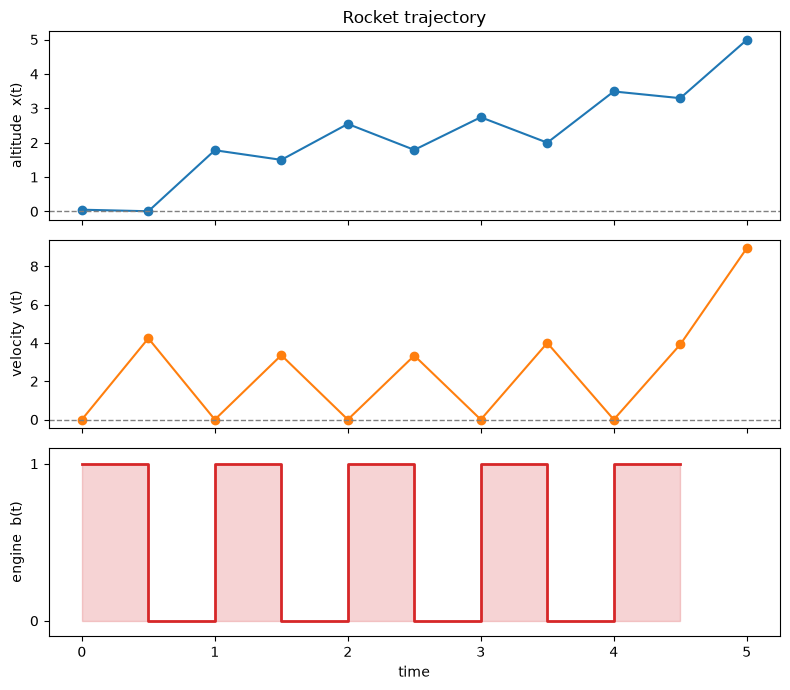

In [ ]:
params = dict(
    N=10,
    J=3,
    dt=0.5,

    a=2,
    beta=10000,
    gamma=10000,
    sigma=10000,

    xmin=0,
    xmax=5,

    vmin=0,
    vmax=20,

    g_grav=10,

    Tmax=20,
    mass=1,

    x0=0,
    v0=0,

    xN=10,
    vN=10,
)

params_test2 = {**params, "beta": params["beta"]*100, "gamma": params["gamma"]*10}
Q_test2 = build_rocket_qubo(**params_test2)

temps, energies, x_best_test2 = sim_annealing_QUBO_converge(
    Q_test2, alpha=0.96, window=50, tol=1e-3, max_sweeps=20000, verbose=True
)

b3, x3, v3 = decode_solution(
    x_best_test2,
    params_test2["N"], params_test2["J"],
    params_test2["xmin"], params_test2["xmax"],
    params_test2["vmin"], params_test2["vmax"]
)

pos_res3, vel_res3 = check_dynamics_residuals(
    b3, x3, v3, params["dt"], params["Tmax"], params["mass"], params["g_grav"]
)
fig = plot_trajectory(b3, x3, v3, dt=params["dt"], savepath="rocket_tuned.pdf")

# testing

In [ ]:
# num_sweeps
#num_temp_steps = int(np.log(T_end / T_start) / np.log(alpha))
#print("your annealer's temperature steps:", num_temp_steps)

T_start, T_end, alpha, sweeps_per_T = 80000, 1, 0.97, 2000

num_temp_steps = np.log(T_end / T_start) / np.log(alpha)
total_sweeps = sweeps_per_T * num_temp_steps
print("temp steps:", num_temp_steps)
print("total sweeps:", total_sweeps)



# dE comparison
x_random = np.random.choice([0, 1], size=Q.shape[0]).astype(np.float64)
dEs = [delta_energy(x_random, Q, i) for i in range(Q.shape[0])]
print("typical |dE| scale:", np.abs(dEs).mean(), np.abs(dEs).max())


temp steps: 370.65251679065597
total sweeps: 741305.0335813119
typical |dE| scale: 68973.91304347826 357000.0


## .

In [ ]:
x = np.random.randint(0, 2, len(Q)).astype(np.float64)

for i in range(len(Q)):
    dE_formula = delta_energy(x, Q, i)

    x2 = x.copy()
    x2[i] = 1 - x2[i]

    dE_exact = energy_QUBO(x2, Q) - energy_QUBO(x, Q)

    if abs(dE_formula - dE_exact) > 1e-8:
        print("Mismatch at bit", i)
        print("formula:", dE_formula)
        print("exact  :", dE_exact)
        break
else:
    print("delta_energy is correct!")

delta_energy is correct!


In [ ]:
x = np.random.randint(0,2,Q.shape[0]).astype(np.float64)

E = energy_QUBO(x,Q)

for k in range(20):
    E = sweep_once_QUBO(x,Q,T=100,E=E)

    E_true = energy_QUBO(x,Q)

    print(k, E, E_true, E-E_true)

0 -667949.4 -667949.4 0.0
1 -726712.1000000003 -726712.1000000001 -2.3283064365386963e-10
2 -759718.6000000002 -759718.6000000001 -1.1641532182693481e-10
3 -762531.0000000003 -762530.9999999999 -4.656612873077393e-10
4 -762732.6000000008 -762732.6000000001 -6.984919309616089e-10
5 -762427.1000000009 -762427.1000000001 -8.149072527885437e-10
6 -762864.600000001 -762864.6000000001 -9.313225746154785e-10
7 -762514.2000000011 -762514.2 -1.1641532182693481e-09
8 -762302.8000000011 -762302.8 -1.0477378964424133e-09
9 -763445.9000000011 -763445.9 -1.0477378964424133e-09
10 -763643.2000000009 -763643.2 -9.313225746154785e-10
11 -763259.7000000008 -763259.7 -8.149072527885437e-10
12 -762103.1000000007 -762103.1 -6.984919309616089e-10
13 -762904.9000000005 -762904.9 -4.656612873077393e-10
14 -762771.9000000005 -762771.9 -4.656612873077393e-10
15 -762500.2000000011 -762500.2 -1.1641532182693481e-09
16 -762988.9000000013 -762988.8999999999 -1.3969838619232178e-09
17 -762803.6000000008 -762803.6 -8

In [ ]:
b, x, v = decode_solution(x_best, params["N"], params["J"],
                           params["xmin"], params["xmax"],
                           params["vmin"], params["vmax"])

dt=0.5
g_grav=10
Tmax=10000
mass=1

alpha=5
beta=11000
gamma=1000
sigma=1000

x0=0
v0=0
xN=10
vN=0

fuel = alpha * sum(b)

pos = 0
for k in range(N):
    r = x[k+1] - x[k] - dt*v[k]
    pos += beta * r*r

vel = 0
for k in range(N):
    r = v[k+1] - v[k] - dt*(Tmax/mass*b[k] - g_grav)
    vel += gamma * r*r

bc = sigma*((x[0]-x0)**2 + (v[0]-v0)**2)
bc += sigma*((x[-1]-xN)**2 + (v[-1]-vN)**2)

print(fuel)def add_position_dynamics(Q, N, J, beta, dt, xmin, xmax, vmin, vmax):
    """E_x_dyn = beta * sum_k (x_{k+1} - x_k - dt*v_k)^2"""
    wx, Ax = encoding_coeffs(xmin, xmax, J)
    wv, Av = encoding_coeffs(vmin, vmax, J)
 
    #using .get(gi,0,0) sets =0 if we havent seen it before
    for k in range(N):
        terms = {}
        for bit, w in enumerate(wx):
            gi = idx("x", k + 1, bit, N, J)
            terms[gi] = terms.get(gi, 0.0) + w
        for bit, w in enumerate(wx):
            gi = idx("x", k, bit, N, J)
            terms[gi] = terms.get(gi, 0.0) - w
        for bit, w in enumerate(wv):
            gi = idx("v", k, bit, N, J)
            terms[gi] = terms.get(gi, 0.0) - dt * w
 
        # constant piece: Ax - Ax - dt*Av = -dt*Av
        C = -dt * Av
        add_square(Q, terms, C, beta)
print(pos)
print(vel)
print(bc)
print(fuel+pos+vel+bc)

0.0
82499999.99999996
35975000.0
11224999.999999996
129699999.99999996


In [ ]:
Q_sym = build_rocket_qubo(**params)

x_test = np.random.choice([0, 1], size=Q_sym.shape[0]).astype(np.float64)

E_direct = energy_QUBO(x_test, Q_sym)

# now manually recompute via sum of deltas from an all-zero start
x0 = np.zeros_like(x_test)
E0 = energy_QUBO(x0, Q_sym)  # should be 0 if no linear... check this
E_incremental = E0
for i in range(len(x_test)):
    if x_test[i] == 1:
        dE = delta_energy(x0, Q_sym, i)
        E_incremental += dE
        x0[i] = 1

print("direct:", E_direct)
print("incremental:", E_incremental)

direct: 615000.0
incremental: 615000.0


In [ ]:
x = np.random.randint(0,2,Q.shape[0]).astype(np.float64)

E = energy_QUBO(x,Q)

E2, s = sweep_until_converged(x,Q,100,E)

print(E2)
print(energy_QUBO(x,Q))
print(E2-energy_QUBO(x,Q))

-713422.4000000202
-713422.4
-2.0139850676059723e-08


## dwave

In [ ]:
import neal
params = dict(
    N=20,
    J=1,
    dt=0.5,

    alpha=0,
    beta=1000,
    gamma=1000,
    sigma=1000,

    xmin=0,
    xmax=10,

    vmin=-10,
    vmax=10,

    g_grav=10,

    Tmax=20,
    mass=1,

    x0=0,
    v0=0,

    xN=10,
    vN=0,
)

Q_matrix = build_rocket_qubo(**params)

Q_dict = {}
n = Q_matrix.shape[0]
for i in range(n):
    for j in range(i, n):
        if Q_matrix[i, j] != 0:
            Q_dict[(i, j)] = Q_matrix[i, j]

sampler = neal.SimulatedAnnealingSampler()
sampleset = sampler.sample_qubo(Q_dict, num_reads=1000, num_sweeps=5000)



#energies = sampleset.record.energy
#print("min:", energies.min(), "std:", energies.std())

KeyboardInterrupt: 

min: -1408000.0
mean: -1394604.0
std: 10929.006542225145


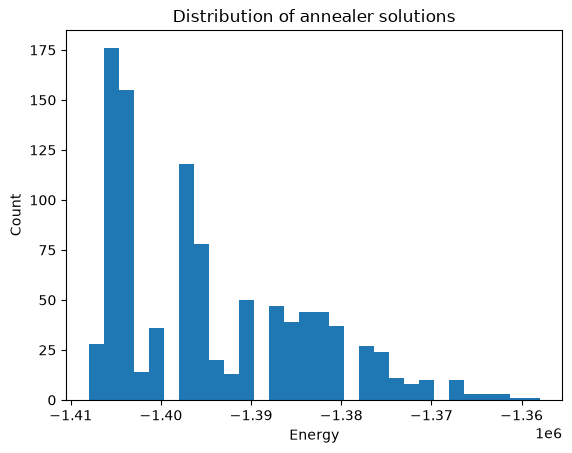

In [ ]:
energies = sampleset.record.energy
print("min:", energies.min())
print("mean:", energies.mean())
print("std:", energies.std())

import matplotlib.pyplot as plt
plt.hist(energies, bins=30)
plt.xlabel("Energy")
plt.ylabel("Count")
plt.title("Distribution of annealer solutions")
plt.show()